<div align="center" style="
    background: linear-gradient(135deg, #667eea, #764ba2);
    padding:35px;
    border-radius:15px;
    box-shadow:0 8px 25px rgba(0,0,0,0.25);
">
  <h1 style="
      color:white;
      font-family: 'Segoe UI', sans-serif;
      margin:0;
      font-size:42px;
      letter-spacing:1px;
  ">
    Outliers Detection Removal
  </h1>
</div>

<h3 style="
    text-align:left;
    font-family: 'Georgia', serif;
    font-weight:600;
    letter-spacing:1.5px;
    color:#2c3e50;
">
    🏠 99 Acres by Prince Kumar
</h3>

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\Jyoti\99 Acers\Featue_Engeineing\Gurgaon_House_Flat_Cleaned_FE.csv")

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2668 entries, 0 to 2667
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       2668 non-null   int64  
 1   property_name    2668 non-null   object 
 2   per_sqft         2668 non-null   float64
 3   bedroom          2668 non-null   int64  
 4   bathroom         2668 non-null   int64  
 5   configuration    2668 non-null   int64  
 6   area             2668 non-null   float64
 7   area_type        2668 non-null   object 
 8   floor_number     2668 non-null   float64
 9   facing           2668 non-null   object 
 10  age_possession   2668 non-null   object 
 11  location         2668 non-null   object 
 12  property_type    2668 non-null   object 
 13  price_cr         2668 non-null   float64
 14  Luxury_score     2668 non-null   int64  
 15  society_encoded  2668 non-null   float64
 16  sector_encoded   2668 non-null   float64
dtypes: float64(6),

In [4]:
df.duplicated().sum()

0

In [5]:
df.head()

,Unnamed: 0,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,location,property_type,price_cr,Luxury_score,society_encoded,sector_encoded
0,0,Sector 104,14740.0,2,2,2,1099.0,Super Built-up,26.0,North-East,Ready To Move,Hero Homes,Flat,1.62,6,2.071224,2.838395
1,1,Sector 37C,9010.0,4,4,4,1848.0,Super Built-up,0.0,West,Ready To Move,Piedmont Taksila heights,Flat,1.67,0,1.842000,1.740714
2,2,Sector 30,30167.0,4,4,4,5138.0,Carpet,0.0,North,Ready To Move,Unitech The World Spa West,Flat,15.50,0,13.566667,9.437500
3,3,Sector 89,9714.0,3,3,3,1750.0,Built-up,0.0,East,Under Construction,Ace Palm Floors,Flat,1.70,12,1.700000,1.780870
4,4,Sector 104,12063.0,4,4,4,3150.0,Super Built-up,0.0,Unknown,Ready To Move,ATS Triumph,Flat,3.80,0,3.817222,2.838395


# Price In crore

In [92]:
df['price_cr'].describe()

count    2664.000000
mean        6.404497
std         6.395283
min         0.400000
25%         2.480000
50%         3.950000
75%         8.350000
max        75.000000
Name: price_cr, dtype: float64

C:\Users\Jyoti\AppData\Local\Temp\ipykernel_12152\4121014617.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_cr'])


<Axes: xlabel='price_cr', ylabel='Density'>

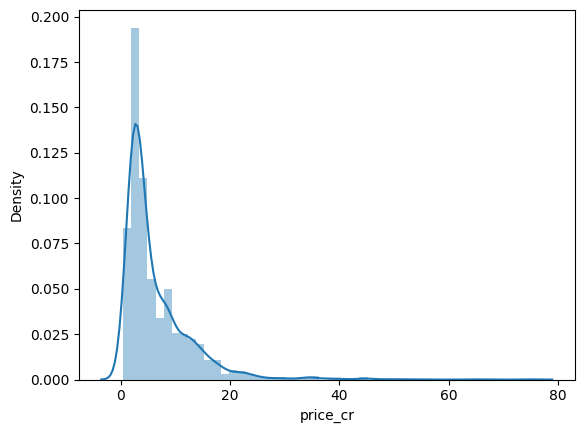

In [93]:
sns.distplot(df['price_cr'])

<Axes: ylabel='price_cr'>

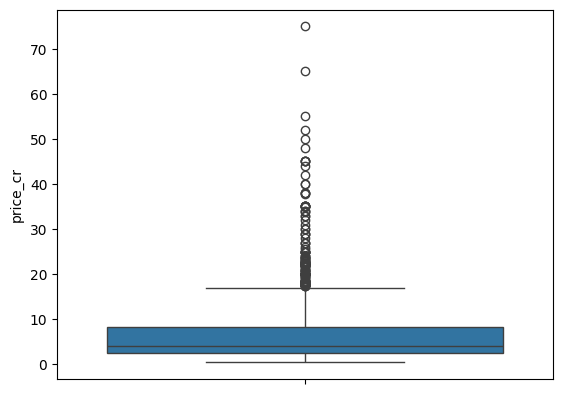

In [94]:
sns.boxplot(df['price_cr'])

In [95]:
# caluating IQR 
Q1 = df['price_cr'].quantile(0.25)
Q3 = df['price_cr'].quantile(0.75)
IQR = Q3-Q1

In [96]:
# defineing bound for Outliers 
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [97]:
lower_bound,upper_bound

(-6.324999999999999, 17.155)

In [98]:
df[df['price_cr'] > upper_bound]

,Unnamed: 0,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,location,property_type,price_cr,Luxury_score,society_encoded,sector_encoded
202,202,Sector 65,57940.0,4,4,4,6050.0,Super Built-up,0.0,East,Ready To Move,Trump Tower,Flat,22.00,0,17.592857,8.432785
259,259,Sector 54,56340.0,4,6,4,3541.0,Super Built-up,30.0,East,Ready To Move,DLF The Crest,Flat,19.95,0,18.612500,22.561538
262,262,Sector 48,40304.0,4,6,4,8684.0,Built-up,16.0,Unknown,Ready To Move,Central Park Resorts Sky Villas,Flat,35.00,0,35.000000,9.550147
325,325,Sector 65,30064.0,7,8,7,11200.0,Super Built-up,25.0,North-East,Ready To Move,M3M Golfestate,Flat,33.67,0,12.860500,8.432785
326,326,Sector 54,52245.0,4,6,4,3541.0,Super Built-up,0.0,East,Ready To Move,DLF The Crest,Flat,18.50,0,18.612500,22.561538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2578,2578,Nirvana Country,38720.0,4,4,4,5940.0,Super Built-up,0.0,Unknown,RESALE,Unitech Espace,House,27.00,12,16.748889,9.316250
2579,2579,Nirvana Country,45454.0,4,5,4,5940.0,Super Built-up,0.0,Unknown,RESALE,"Nirvana Country, Gurgaon",House,27.00,0,16.000000,9.316250
2591,2591,DLF Phase 3,38734.0,8,8,8,4518.0,Super Built-up,2.0,East,RESALE,Cyber City,House,17.50,18,9.848125,10.885385
2611,2611,B Block Sushant Lok Phase 1,61350.0,4,4,4,7335.0,Super Built-up,0.0,North-East,RESALE,"B Block Sushant Lok Phase 1, Gurgaon",House,45.00,30,27.625000,22.000000


In [99]:
# identifing Ouliers 
outliers = df[df['price_cr'] > upper_bound]

In [100]:
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price_cr'].describe()
num_outliers,outliers_price_stats

(146,
 count    146.000000
 mean      25.448493
 std        9.949192
 min       17.250000
 25%       18.500000
 50%       22.000000
 75%       28.750000
 max       75.000000
 Name: price_cr, dtype: float64)

In [101]:
outliers.sort_values('price_cr',ascending=False).head(20)

,Unnamed: 0,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,location,property_type,price_cr,Luxury_score,society_encoded,sector_encoded
2372,2372,DLF Phase 1,83333.0,20,20,20,9000.0,Super Built-up,0.0,East,RESALE,"DLF Phase 1, Gurgaon",House,75.00,6,19.940000,21.432353
654,654,Sector 42,87837.0,4,8,4,7400.0,Super Built-up,8.0,North-East,Ready To Move,DLF The Camellias,Flat,65.00,6,65.000000,30.463636
2293,2293,DLF Phase 1,61111.0,6,6,6,9000.0,Super Built-up,0.0,Unknown,RESALE,DLF Qutub Plaza,House,55.00,0,55.000000,21.432353
1838,1838,DLF Phase 1,56534.0,4,4,4,9198.0,Super Built-up,0.0,Unknown,RESALE,DLF City Plots,House,52.00,12,52.000000,21.432353
1723,1723,Subhash Nagar,100000.0,5,2,5,5000.0,Super Built-up,0.0,Unknown,RESALE,"Subhash Nagar, Gurgaon",House,50.00,0,26.400000,26.400000
454,454,Sector 42,75590.0,4,4,4,6350.0,Super Built-up,10.0,North-East,Ready To Move,DLF The Magnolias,Flat,48.00,7,44.833333,30.463636
2611,2611,B Block Sushant Lok Phase 1,61350.0,4,4,4,7335.0,Super Built-up,0.0,North-East,RESALE,"B Block Sushant Lok Phase 1, Gurgaon",House,45.00,30,27.625000,22.000000
355,355,Sector 42,70843.0,4,4,4,6352.0,Super Built-up,0.0,Unknown,Ready To Move,DLF The Magnolias,Flat,45.00,7,44.833333,30.463636
472,472,Sector 42,70312.0,4,4,4,6400.0,Super Built-up,0.0,East,Ready To Move,DLF The Magnolias,Flat,45.00,0,44.833333,30.463636
930,930,Sector 42,70312.0,4,4,4,6400.0,Super Built-up,0.0,Unknown,Ready To Move,DLF The Magnolias,Flat,45.00,0,44.833333,30.463636


In [ ]:
# on the basis of price_Cr col we can say that there are some geninune outliers and I am keeping Them 

# Price per SQFT

In [39]:
df['per_sqft'].describe()

count      2668.000000
mean      29524.052099
std       44354.312394
min        1318.000000
25%       13784.750000
50%       18518.000000
75%       32731.250000
max      805555.000000
Name: per_sqft, dtype: float64

C:\Users\Jyoti\AppData\Local\Temp\ipykernel_12152\3045303759.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['per_sqft'])


<Axes: xlabel='per_sqft', ylabel='Density'>

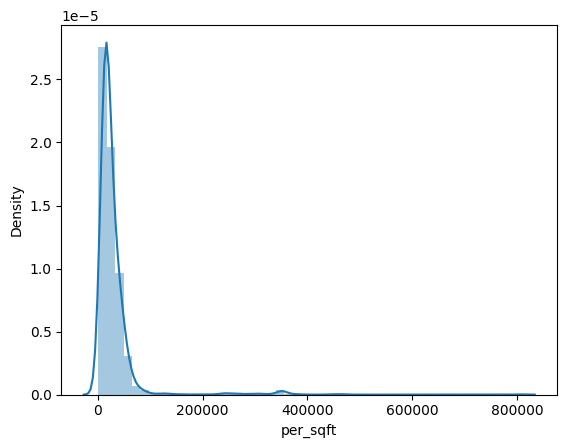

In [29]:
sns.distplot(df['per_sqft'])

<Axes: ylabel='per_sqft'>

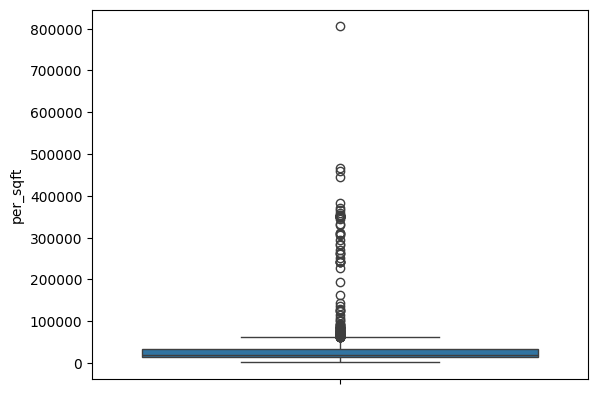

In [30]:
sns.boxplot(df['per_sqft'])

In [31]:
# caluating IQR 
Q1_sqft = df['per_sqft'].quantile(0.25)
Q3_sqft = df['per_sqft'].quantile(0.75)
IQR_sqft = Q3-Q1

In [33]:
# defineing bound for Outliers 
lower_bound_sqft = Q1 - 1.5 * IQR
upper_bound_sqft = Q3 + 1.5 * IQR

In [91]:
lower_bound_sqft,upper_bound_sqft

(-14635.0, 61151.0)

In [35]:
outliers_sqft = df[ df['per_sqft'] > upper_bound_sqft]

In [37]:
num_outliers_sqft = outliers.shape[0]
outliers_price_stats_sqft = outliers['per_sqft'].describe()
num_outliers_sqft,outliers_price_stats_sqft



(147,
 count       147.000000
 mean      54967.639456
 std       69624.859896
 min        5859.000000
 25%       35300.000000
 50%       46667.000000
 75%       57143.000000
 max      805555.000000
 Name: per_sqft, dtype: float64)

In [45]:
df_outliers_sqft = outliers_sqft.sort_values('per_sqft',ascending=False)
df_outliers_sqft.head(20)

,Unnamed: 0,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,location,property_type,price_cr,Luxury_score,society_encoded,sector_encoded
1892,1892,Sector 54,805555.0,5,6,5,360.0,Super Built-up,0.0,East,RESALE,Emaar The Palm Springs,House,29.00,14,29.500000,22.561538
1884,1884,Sushant Lok Phase 1,466666.0,4,4,4,60.0,Super Built-up,0.0,East,RESALE,Ansal Sushant Lok Plots,House,2.80,8,4.350000,12.167600
2001,2001,Pocket H Nirvana Country,458333.0,4,4,4,360.0,Super Built-up,0.0,Unknown,RESALE,"Pocket H Nirvana Country, Gurgaon",House,16.50,30,16.500000,8.333333
2279,2279,Nirvana Country,444444.0,5,5,5,360.0,Super Built-up,0.0,Unknown,RESALE,Nirvana Cedar Crest,House,16.00,12,16.500000,9.316250
2565,2565,Sector 49,383333.0,4,4,4,60.0,Super Built-up,0.0,North,RESALE,South City 2,House,2.30,6,2.300000,4.587949
2564,2564,Sector 109,370370.0,3,3,3,270.0,Super Built-up,0.0,Unknown,RESALE,Sobha International City Phase 3,House,10.00,6,13.261538,9.683529
2575,2575,Sushant Lok Phase 1,365000.0,9,9,9,300.0,Super Built-up,0.0,North,RESALE,Sushant Lok 1 Builder Floors,House,10.95,7,10.950000,12.167600
2413,2413,Sector 49,358974.0,5,6,5,975.0,Super Built-up,0.0,North,RESALE,Eros Rosewood City,House,35.00,6,7.948750,4.587949
1626,1626,C Block Mayfield Garden,354166.0,4,7,4,240.0,Covered,0.0,East,RESALE,"C Block Mayfield Garden, Gurgaon",House,8.50,18,8.250000,8.250000
2310,2310,Sector 109,352941.0,4,4,4,272.0,Super Built-up,0.0,North-East,RESALE,International City by Sobha Phase 1,House,9.60,6,11.018378,9.683529


In [46]:
df_outliers_sqft.shape

(121, 17)

In [53]:
df.drop(index=1892,inplace=True)

In [55]:
df.sort_values('per_sqft',ascending=False).head()

,Unnamed: 0,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,location,property_type,price_cr,Luxury_score,society_encoded,sector_encoded
1884,1884,Sushant Lok Phase 1,466666.0,4,4,4,60.0,Super Built-up,0.0,East,RESALE,Ansal Sushant Lok Plots,House,2.8,8,4.350000,12.167600
2001,2001,Pocket H Nirvana Country,458333.0,4,4,4,360.0,Super Built-up,0.0,Unknown,RESALE,"Pocket H Nirvana Country, Gurgaon",House,16.5,30,16.500000,8.333333
2279,2279,Nirvana Country,444444.0,5,5,5,360.0,Super Built-up,0.0,Unknown,RESALE,Nirvana Cedar Crest,House,16.0,12,16.500000,9.316250
2565,2565,Sector 49,383333.0,4,4,4,60.0,Super Built-up,0.0,North,RESALE,South City 2,House,2.3,6,2.300000,4.587949
2564,2564,Sector 109,370370.0,3,3,3,270.0,Super Built-up,0.0,Unknown,RESALE,Sobha International City Phase 3,House,10.0,6,13.261538,9.683529


C:\Users\Jyoti\AppData\Local\Temp\ipykernel_12152\3045303759.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['per_sqft'])


<Axes: xlabel='per_sqft', ylabel='Density'>

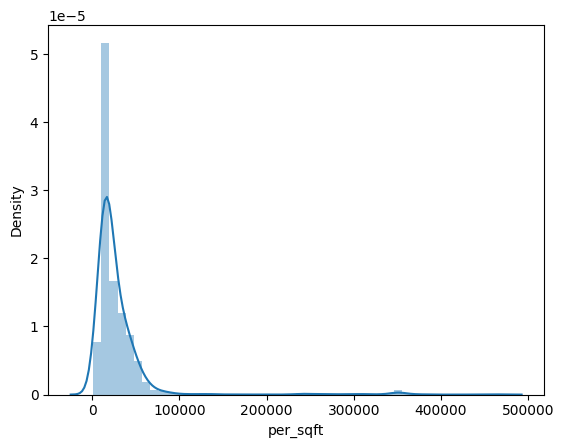

In [56]:
sns.distplot(df['per_sqft'])

In [59]:
df['per_sqft'].describe()

count      2667.000000
mean      29233.076865
std       41738.085352
min        1318.000000
25%       13783.500000
50%       18518.000000
75%       32698.000000
max      466666.000000
Name: per_sqft, dtype: float64

In [ ]:
# I tried to find anomly or data error but they all were real data points.
# I found 1 value which was far from all other data points affecting mean directly so i dropped it.

# Area

In [60]:
df['area'].describe()

count     2667.000000
mean      2550.767154
std       2100.232758
min         56.000000
25%       1609.000000
50%       2107.000000
75%       2929.500000
max      59400.000000
Name: area, dtype: float64

C:\Users\Jyoti\AppData\Local\Temp\ipykernel_12152\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

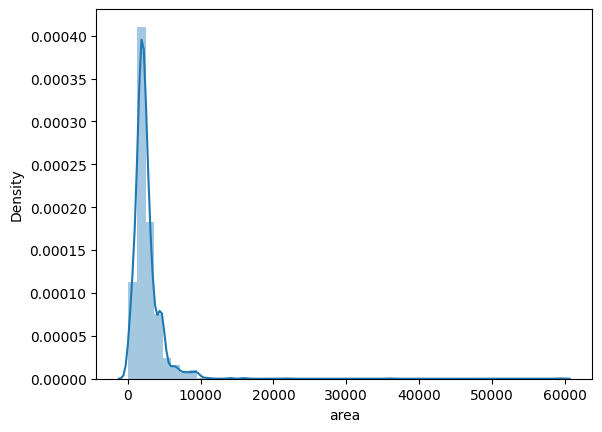

In [61]:
sns.distplot(df['area'])

<Axes: ylabel='area'>

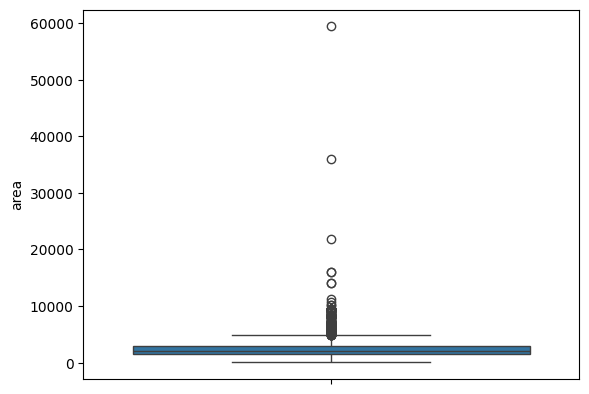

In [62]:
sns.boxplot(df['area'])

In [64]:
df.sort_values('area',ascending=False).head(20)

,Unnamed: 0,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,location,property_type,price_cr,Luxury_score,society_encoded,sector_encoded
2159,2159,Suncity,1852.0,5,6,5,59400.0,Built-up,0.0,Unknown,RESALE,"Suncity, Gurgaon",House,11.00,0,14.625000,17.568182
2452,2452,Sector 109,2685.0,5,6,5,36000.0,Super Built-up,0.0,Unknown,RESALE,Sobha International City Phase 3,House,14.50,6,13.261538,9.683529
2665,2665,Sector 109,4755.0,4,4,4,21870.0,Super Built-up,0.0,North-East,RESALE,Sobha International City Phase 3,House,10.40,22,13.261538,9.683529
1919,1919,Malibu Town,23750.0,6,6,6,16000.0,Super Built-up,0.0,North-East,RESALE,Malibu Towne,House,38.00,6,12.058889,10.055652
1918,1918,Sector 46,9250.0,16,15,16,16000.0,Super Built-up,4.0,North-East,RESALE,RWA Sector 46,House,14.80,12,7.885000,10.249630
2036,2036,Suncity,25000.0,7,8,7,14000.0,Built-up,0.0,Unknown,RESALE,Spacious Villa in Suncity,House,35.00,6,35.000000,17.568182
2037,2037,Suncity,25000.0,7,8,7,14000.0,Built-up,0.0,Unknown,RESALE,Spacious Villa,House,35.00,6,19.116667,17.568182
325,325,Sector 65,30064.0,7,8,7,11200.0,Super Built-up,25.0,North-East,Ready To Move,M3M Golfestate,Flat,33.67,0,12.860500,8.432785
2234,2234,Sector 33,28704.0,7,8,7,10800.0,Super Built-up,0.0,Unknown,RESALE,Unitech Uniworld Resorts,House,31.00,0,13.344516,13.652424
2003,2003,Sector 46,34203.0,6,7,6,10233.0,Super Built-up,0.0,Unknown,RESALE,Unitech Vista Villas,House,35.00,13,22.952500,10.249630


In [65]:
df = df[df['area'] < 20000]

In [67]:
df.sort_values('area',ascending=False).head(5)

,Unnamed: 0,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,location,property_type,price_cr,Luxury_score,society_encoded,sector_encoded
1918,1918,Sector 46,9250.0,16,15,16,16000.0,Super Built-up,4.0,North-East,RESALE,RWA Sector 46,House,14.80,12,7.885000,10.249630
1919,1919,Malibu Town,23750.0,6,6,6,16000.0,Super Built-up,0.0,North-East,RESALE,Malibu Towne,House,38.00,6,12.058889,10.055652
2036,2036,Suncity,25000.0,7,8,7,14000.0,Built-up,0.0,Unknown,RESALE,Spacious Villa in Suncity,House,35.00,6,35.000000,17.568182
2037,2037,Suncity,25000.0,7,8,7,14000.0,Built-up,0.0,Unknown,RESALE,Spacious Villa,House,35.00,6,19.116667,17.568182
325,325,Sector 65,30064.0,7,8,7,11200.0,Super Built-up,25.0,North-East,Ready To Move,M3M Golfestate,Flat,33.67,0,12.860500,8.432785


C:\Users\Jyoti\AppData\Local\Temp\ipykernel_12152\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

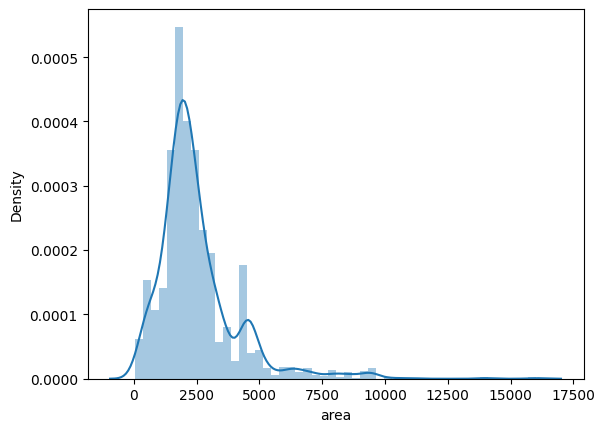

In [68]:
sns.distplot(df['area'])

<Axes: ylabel='area'>

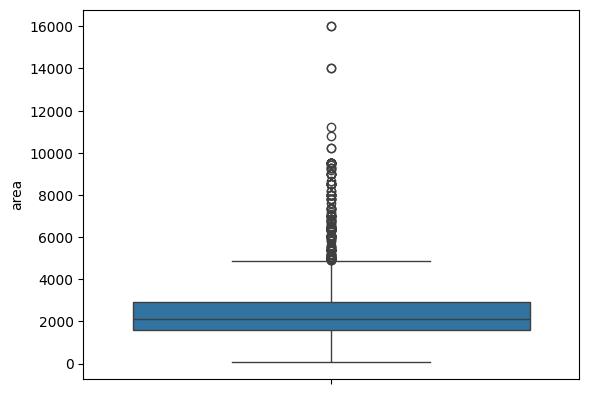

In [69]:
sns.boxplot(df['area'])

In [70]:
df['area'].describe()

count     2664.000000
mean      2509.619369
std       1624.913602
min         56.000000
25%       1608.000000
50%       2105.000000
75%       2912.000000
max      16000.000000
Name: area, dtype: float64

In [ ]:
# I dropped 3 rows Which were affecting the Distribution of Col

In [77]:
df.shape

(2664, 17)

# Configuration

In [80]:
df['configuration'].describe()

count    2664.000000
mean        4.216592
std         2.900660
min         1.000000
25%         3.000000
50%         3.000000
75%         5.000000
max        48.000000
Name: configuration, dtype: float64

C:\Users\Jyoti\AppData\Local\Temp\ipykernel_12152\3702194903.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['configuration'])


<Axes: xlabel='configuration', ylabel='Density'>

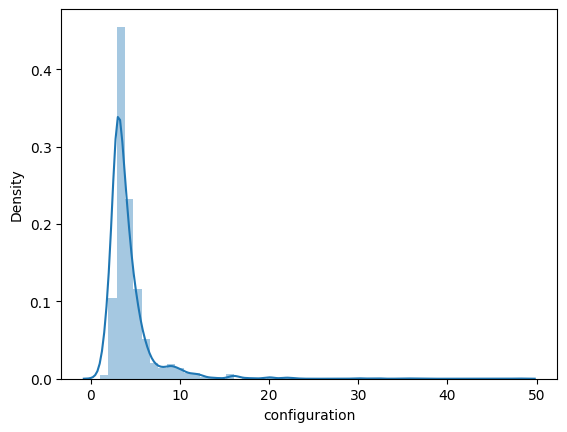

In [81]:
sns.distplot(df['configuration'])

<Axes: ylabel='configuration'>

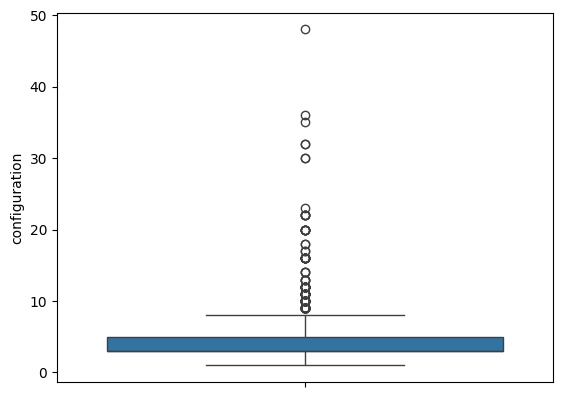

In [82]:
sns.boxplot(df['configuration'])

In [83]:
df.sort_values('configuration',ascending=False).head(10)

,Unnamed: 0,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,location,property_type,price_cr,Luxury_score,society_encoded,sector_encoded
2500,2500,Sector 55,35651.0,48,50,48,5049.0,Super Built-up,0.0,Unknown,RESALE,Sector-55,House,18.0,0,18.000,8.131250
2313,2313,Sector 38,41929.0,36,36,36,4770.0,Super Built-up,0.0,North-East,RESALE,"Sector 38, Gurgaon",House,20.0,7,20.000,10.166667
2031,2031,S Block DLF Phase 3,46667.0,35,35,35,4500.0,Covered,0.0,Unknown,RESALE,"S Block DLF Phase 3, Gurgaon",House,21.0,12,11.395,11.930000
2314,2314,Sector 52,59761.0,32,32,32,4518.0,Super Built-up,0.0,Unknown,RESALE,Sector 52,House,27.0,7,27.000,5.501818
2496,2496,Greenwood City,44444.0,32,34,32,4500.0,Super Built-up,4.0,Unknown,RESALE,"Greenwood City, Gurgaon",House,20.0,7,22.070,21.308333
2139,2139,Sector 1 Imt Manesar,20645.0,30,27,30,4843.0,Super Built-up,0.0,Unknown,RESALE,"Sector 1 Imt Manesar, Gurgaon",House,10.0,0,7.050,5.243333
2362,2362,Sector 1 Imt Manesar,20439.0,30,27,30,2690.0,Super Built-up,0.0,Unknown,RESALE,"Sector 1 Imt Manesar, Gurgaon",House,5.5,0,7.050,5.243333
2487,2487,DLF Golf Course,57547.0,23,24,23,4518.0,Super Built-up,0.0,Unknown,RESALE,"DLF Golf Course, Gurgaon",House,26.0,0,17.800,26.533333
1754,1754,Patel Nagar,34188.0,22,22,22,1755.0,Super Built-up,5.0,Unknown,RESALE,"Patel Nagar, Gurgaon",House,6.0,12,4.625,4.625000
1815,1815,V Block DLF Phase 3,66666.0,22,22,22,1350.0,Super Built-up,0.0,Unknown,RESALE,"V Block DLF Phase 3, Gurgaon",House,9.0,12,9.000,6.586000


In [ ]:
# I was looking for error or anommly but they all are real values 

# Luxury Score 

In [84]:
df['Luxury_score'].describe()

count    2664.000000
mean        5.402778
std         7.506433
min         0.000000
25%         0.000000
50%         6.000000
75%         6.000000
max        71.000000
Name: Luxury_score, dtype: float64

C:\Users\Jyoti\AppData\Local\Temp\ipykernel_12152\1702660188.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Luxury_score'])


<Axes: xlabel='Luxury_score', ylabel='Density'>

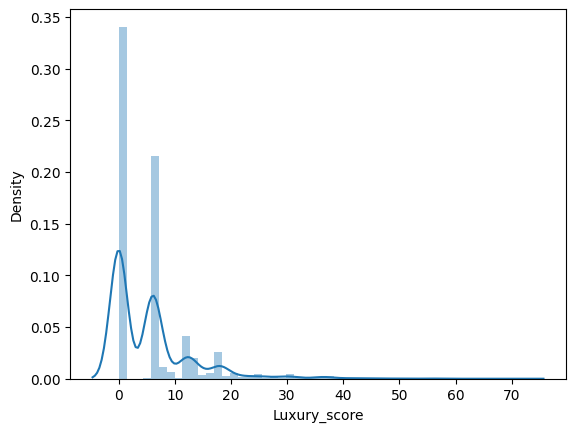

In [85]:
sns.distplot(df['Luxury_score'])

<Axes: ylabel='Luxury_score'>

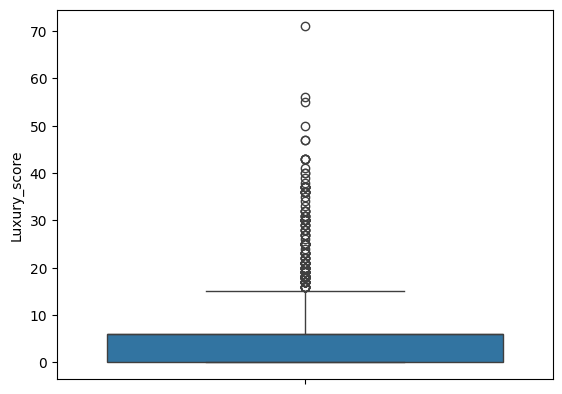

In [86]:
sns.boxplot(df['Luxury_score'])

In [87]:
df.sort_values('Luxury_score',ascending=False).head(10)

,Unnamed: 0,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,location,property_type,price_cr,Luxury_score,society_encoded,sector_encoded
2174,2174,Sector 33,38833.0,4,4,4,9000.0,Super Built-up,0.0,Unknown,RESALE,Unitech The Residences,House,34.95,71,34.950000,13.652424
595,595,Sector 70,12307.0,3,5,3,1950.0,Super Built-up,0.0,North-East,Ready To Move,Shree Vardhman Victoria,Flat,2.40,56,2.304545,2.246154
2635,2635,Malibu Town,27018.0,7,7,7,5526.0,Built-up,0.0,North-East,RESALE,Malibu Towne,House,14.93,55,12.058889,10.055652
1380,1380,Sector 48,27822.0,3,3,3,1869.0,Super Built-up,0.0,Unknown,Ready To Move,Central Park Resorts,Flat,5.20,50,7.475000,9.550147
1223,1223,Sector 37C,10869.0,4,4,4,1932.0,Carpet,0.0,Unknown,Ready To Move,Piedmont Taksila heights,Flat,2.10,47,1.842000,1.740714
6,6,Sector 37C,10869.0,4,4,4,1932.0,Carpet,0.0,Unknown,Ready To Move,Piedmont Taksila heights,Flat,2.10,47,1.842000,1.740714
1895,1895,Malibu Town,242671.0,10,10,10,614.0,Super Built-up,0.0,North-East,RESALE,Malibu Towne,House,14.90,43,12.058889,10.055652
582,582,Sector 70,12717.0,3,3,3,1950.0,Super Built-up,0.0,North-East,Ready To Move,Shree Vardhman Victoria,Flat,2.48,43,2.304545,2.246154
1053,1053,Sector 47,21255.0,3,5,3,2470.0,Super Built-up,0.0,Unknown,Ready To Move,Bestech Park View Spa,Flat,5.25,43,6.374000,6.442500
1026,1026,Sector 47,21255.0,3,5,3,2470.0,Super Built-up,0.0,Unknown,Ready To Move,Bestech Park View Spa,Flat,5.25,43,6.374000,6.442500


In [88]:
df.shape

(2664, 17)

In [102]:
df.head()

,Unnamed: 0,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,location,property_type,price_cr,Luxury_score,society_encoded,sector_encoded
0,0,Sector 104,14740.0,2,2,2,1099.0,Super Built-up,26.0,North-East,Ready To Move,Hero Homes,Flat,1.62,6,2.071224,2.838395
1,1,Sector 37C,9010.0,4,4,4,1848.0,Super Built-up,0.0,West,Ready To Move,Piedmont Taksila heights,Flat,1.67,0,1.842000,1.740714
2,2,Sector 30,30167.0,4,4,4,5138.0,Carpet,0.0,North,Ready To Move,Unitech The World Spa West,Flat,15.50,0,13.566667,9.437500
3,3,Sector 89,9714.0,3,3,3,1750.0,Built-up,0.0,East,Under Construction,Ace Palm Floors,Flat,1.70,12,1.700000,1.780870
4,4,Sector 104,12063.0,4,4,4,3150.0,Super Built-up,0.0,Unknown,Ready To Move,ATS Triumph,Flat,3.80,0,3.817222,2.838395


In [103]:
df.isnull().sum()

Unnamed: 0         0
property_name      0
per_sqft           0
bedroom            0
bathroom           0
configuration      0
area               0
area_type          0
floor_number       0
facing             0
age_possession     0
location           0
property_type      0
price_cr           0
Luxury_score       0
society_encoded    0
sector_encoded     0
dtype: int64

In [104]:
df.to_csv('Gugaon_Properties_Outliers_Treated.csv',index=False)